# Module 4: Deep Learning — Brain Tumor Classification & Transfer Learning
**Course**: Computer Vision | Christian Mata, PhD

**Dataset**: LGG Brain MRI Segmentation (Kaggle — mateuszbuda)

**Task**: Binary classification — does this MRI slice contain a tumor? (yes / no)

**Labels**: Derived from the segmentation masks — if any pixel in the mask is non-zero, the slice contains a tumor.

**Group members**: Martin Çaro, Edison Zyberaj

# Brain Tumor Classification
**Requires 01_train_test.** Loads pre-split data from Drive, trains CNN, saves model.

## 1. Mount Drive and check setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/CV_Project'
os.makedirs(DRIVE + '/brain/images', exist_ok=True)
os.makedirs(DRIVE + '/brain/masks',  exist_ok=True)
os.makedirs(DRIVE + '/splits',       exist_ok=True)
os.makedirs(DRIVE + '/models',       exist_ok=True)
os.makedirs(DRIVE + '/results',      exist_ok=True)
print('Drive mounted ✓  —  ' + DRIVE)

Mounted at /content/drive
Drive mounted ✓  —  /content/drive/MyDrive/CV_Project


In [3]:
import os, numpy as np
assert os.path.exists(DRIVE + '/splits/x_train.npy'),     '❌ Run 01_train_test.ipynb first.'
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

x_train = np.load(DRIVE + '/splits/x_train.npy')
x_test  = np.load(DRIVE + '/splits/x_test.npy')
y_train = np.load(DRIVE + '/splits/y_train.npy')
y_test  = np.load(DRIVE + '/splits/y_test.npy')

num_classes  = 2
input_shape  = (128, 128, 3)
label_names  = ['no tumor', 'tumor']

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print(f'x_train: {x_train.shape}  |  x_test: {x_test.shape}')
print(f'Tumor in test set: {y_test.sum()}/{len(y_test)}')

x_train: (3143, 128, 128, 3)  |  x_test: (786, 128, 128, 3)
Tumor in test set: 276/786


## 2. Visualize one sample per class

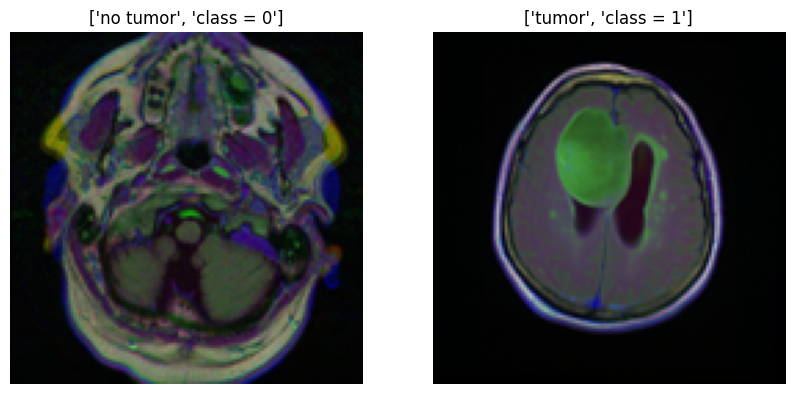

In [4]:
fig = plt.figure(figsize=(10, 5))
for kclass in range(2):
    ind = np.argwhere(y_train == kclass)
    ax  = fig.add_subplot(1, 2, kclass + 1)
    ax.imshow(x_train[ind[0][0]])
    ax.set_title([label_names[kclass], 'class = {}'.format(kclass)])
    ax.axis('off')

## 3. Build the CNN

In [5]:
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(name='features'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Flatten)              │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train

In [6]:
batch_size = 32
epochs     = 15

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.6733 - loss: 0.6194 - val_accuracy: 0.7143 - val_loss: 0.4964
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7454 - loss: 0.4948 - val_accuracy: 0.8095 - val_loss: 0.4163
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7832 - loss: 0.4503 - val_accuracy: 0.8190 - val_loss: 0.4083
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8059 - loss: 0.4121 - val_accuracy: 0.8095 - val_loss: 0.3949
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8236 - loss: 0.3751 - val_accuracy: 0.8127 - val_loss: 0.4156
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8380 - loss: 0.3415 - val_accuracy: 0.8349 - val_loss: 0.3620
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8670 - loss: 0.3039 - val_accuracy: 0.8571 - val_loss: 0.3354
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8773 - loss: 0.2774 - val_accuracy: 0.8444 - 

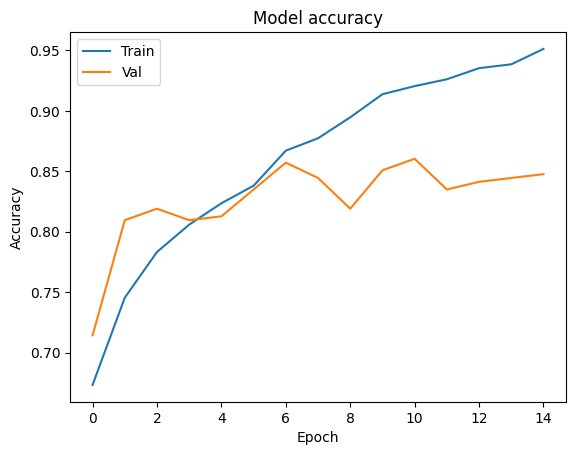

In [7]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy'); plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.savefig(DRIVE + '/results/classification_accuracy.png', dpi=120)
plt.show()

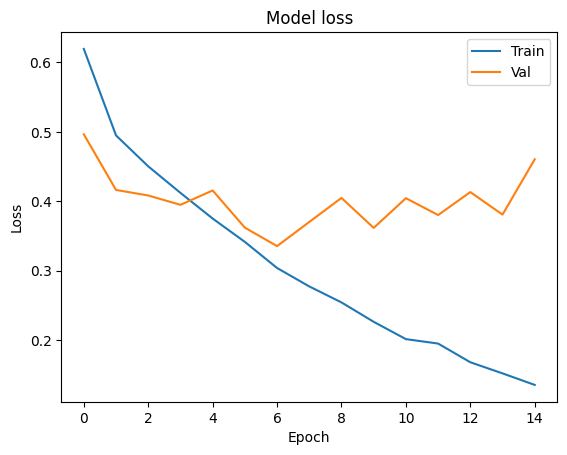

In [8]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.savefig(DRIVE + '/results/classification_loss.png', dpi=120)
plt.show()

## 5. Evaluate

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

score = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

y_test_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_test_pred, target_names=label_names))
print(confusion_matrix(y_test, y_test_pred))

Test loss:     0.514036238193512
Test accuracy: 0.8244274854660034
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

    no tumor       0.89      0.84      0.86       510
       tumor       0.73      0.80      0.76       276

    accuracy                           0.82       786
   macro avg       0.81      0.82      0.81       786
weighted avg       0.83      0.82      0.83       786

[[427  83]
 [ 55 221]]


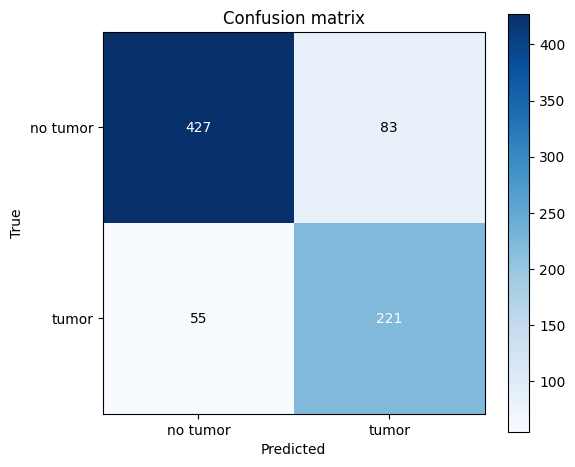

In [10]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(np.arange(num_classes)); ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(label_names); ax.set_yticklabels(label_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2. else 'black')
ax.set_title('Confusion matrix'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(DRIVE + '/results/confusion_matrix.png', dpi=120)
plt.show()

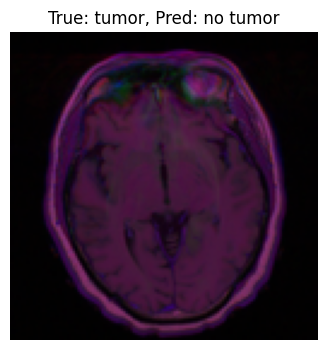

True: tumor | Pred: no tumor


In [11]:
isel = np.where((y_test == 1) & (y_test_pred == 0))[0]
if len(isel) > 0:
    idx = isel[0]
    plt.figure(figsize=(4, 4))
    plt.imshow(x_test[idx])
    plt.title('True: {}, Pred: {}'.format(label_names[y_test[idx]], label_names[y_test_pred[idx]]))
    plt.axis('off'); plt.show()
    print('True:', label_names[y_test[idx]], '| Pred:', label_names[y_test_pred[idx]])
else:
    print('No false negatives found.')

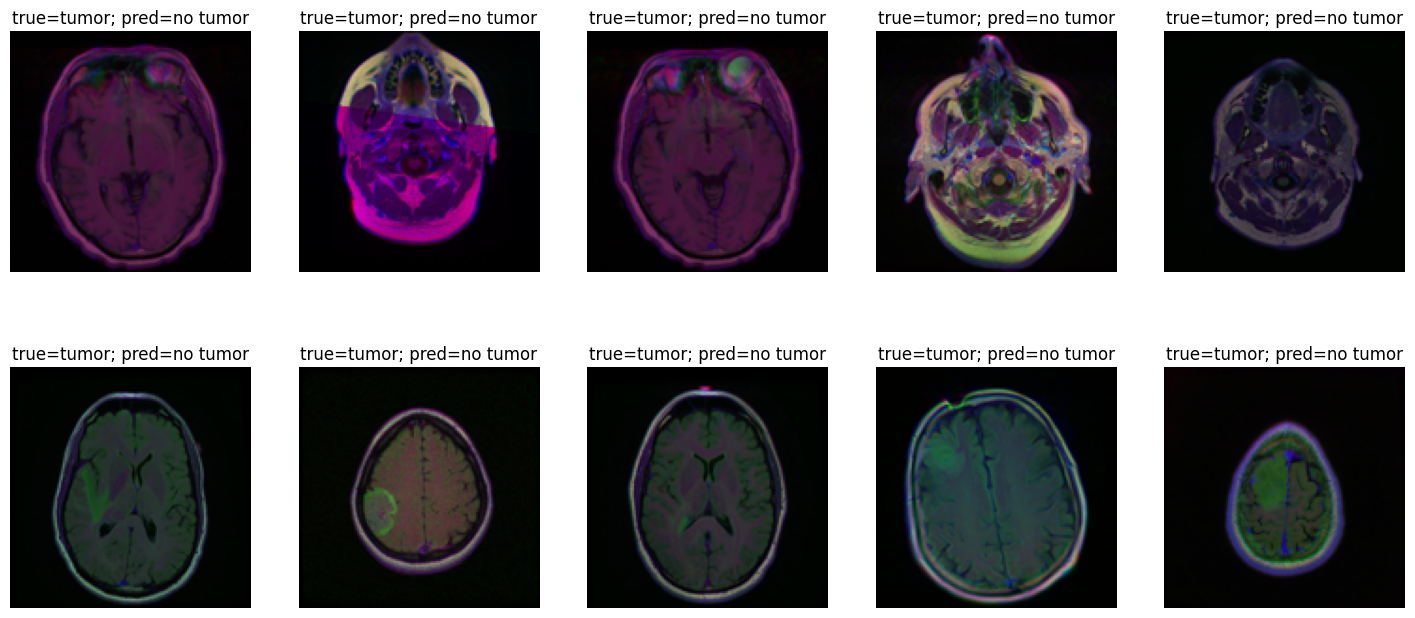

In [12]:
isel   = np.squeeze(np.where((y_test == 1) & (y_test_pred == 0)))
n_show = min(10, len(np.atleast_1d(isel)))
fig    = plt.figure(figsize=(18, 8))
cnt    = 0
for k in np.atleast_1d(isel)[:n_show]:
    cnt += 1
    ax = fig.add_subplot(2, 5, cnt)
    ax.imshow(x_test[k])
    ax.set_title('true={}; pred={}'.format(label_names[y_test[k]], label_names[y_test_pred[k]]))
    ax.axis('off')

## 6. Prediction probabilities

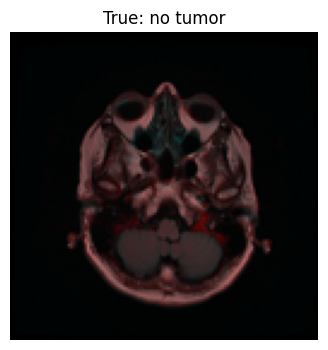

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
Most likely:   no tumor -- P = 0.6375929
Second:        tumor -- P = 0.36240706


In [13]:
isel = 0
plt.figure(figsize=(4, 4))
plt.imshow(x_test[isel]); plt.title('True: ' + label_names[y_test[isel]])
plt.axis('off'); plt.show()

probabilities = model.predict(np.array([x_test[isel]]))
index         = np.argsort(probabilities[0, :])
print('Most likely:  ', label_names[index[1]], '-- P =', probabilities[0, index[1]])
print('Second:       ', label_names[index[0]], '-- P =', probabilities[0, index[0]])

## 7. Save model to Drive

In [14]:
model.save(DRIVE + '/models/brain_tumor_classifier.h5')
print('Model saved to Drive ✓')
from keras.models import load_model
loaded = load_model(DRIVE + '/models/brain_tumor_classifier.h5')
print('Reloaded. Accuracy:', loaded.evaluate(x_test, y_test_cat, verbose=0)[1])

Model saved to Drive ✓
Reloaded. Accuracy: 0.8244274854660034


## 8. Transfer Learning

In [15]:
import tensorflow as tf

x_train_tl = (x_train * 2.0 - 1.0).astype(np.float32)
x_test_tl  = (x_test  * 2.0 - 1.0).astype(np.float32)
print(f'TL input range: {x_train_tl.min():.1f} to {x_train_tl.max():.1f}')

TL input range: -1.0 to 1.0


In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs   = tf.keras.Input(shape=(128, 128, 3))
x        = base_model(inputs, training=False)
x        = tf.keras.layers.GlobalAveragePooling2D()(x)
x        = tf.keras.layers.Dropout(0.3)(x)
outputs  = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
tl_model = tf.keras.Model(inputs, outputs, name='MobileNetV2_classifier')

tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
tl_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=['accuracy']
)

hist_tl = tl_model.fit(
    x_train_tl, y_train_cat,
    batch_size=32, epochs=10,
    validation_split=0.1
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 53s 346ms/step - accuracy: 0.6955 - loss: 0.6496 - val_accuracy: 0.7905 - val_loss: 0.4614
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7507 - loss: 0.5160 - val_accuracy: 0.7778 - val_loss: 0.4290
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7641 - loss: 0.4838 - val_accuracy: 0.8222 - val_loss: 0.4081
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7822 - loss: 0.4525 - val_accuracy: 0.8095 - val_loss: 0.3983
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8013 - loss: 0.4370 - val_accuracy: 0.8127 - val_loss: 0.4057
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8006 - loss: 0.4374 - val_accuracy: 0.8127 - val_loss: 0.3879
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8027 - loss: 0.4266 - val_accuracy: 0.8286 - val_loss: 0.3885
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8101 - loss: 0.4162 - val_accuracy: 0.8222 -

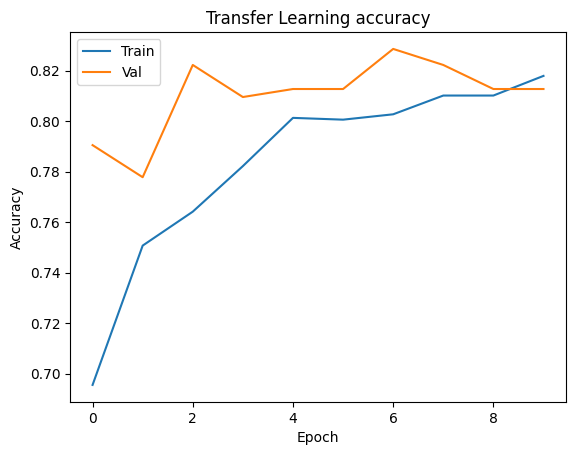

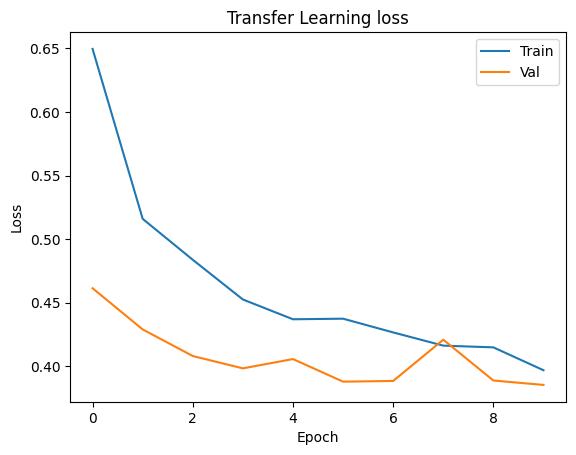

In [18]:
plt.plot(hist_tl.history['accuracy'])
plt.plot(hist_tl.history['val_accuracy'])
plt.title('Transfer Learning accuracy')
plt.ylabel('Accuracy'); plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

plt.plot(hist_tl.history['loss'])
plt.plot(hist_tl.history['val_loss'])
plt.title('Transfer Learning loss')
plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

score_tl  = tl_model.evaluate(x_test_tl, y_test_cat, verbose=0)
y_pred_tl = np.argmax(tl_model.predict(x_test_tl), axis=1)

print('Test accuracy:', score_tl[1])
print(classification_report(y_test, y_pred_tl, target_names=label_names))
print(confusion_matrix(y_test, y_pred_tl))

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 199ms/step
Test accuracy: 0.7938931584358215
              precision    recall  f1-score   support

    no tumor       0.80      0.90      0.85       510
       tumor       0.77      0.59      0.67       276

    accuracy                           0.79       786
   macro avg       0.79      0.75      0.76       786
weighted avg       0.79      0.79      0.79       786

[[461  49]
 [113 163]]


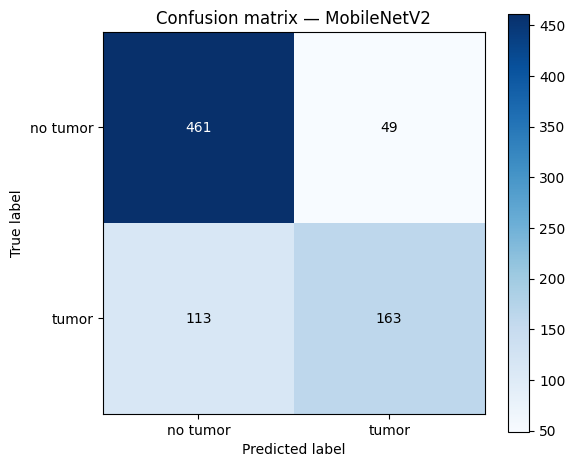

In [20]:
cm_tl = confusion_matrix(y_test, y_pred_tl)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_tl, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(np.arange(num_classes)); ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(label_names); ax.set_yticklabels(label_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm_tl[i, j], 'd'), ha='center', va='center',
                color='white' if cm_tl[i, j] > cm_tl.max() / 2. else 'black')
ax.set_title('Confusion matrix — MobileNetV2')
ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.savefig(DRIVE + '/results/confusion_matrix_tl.png', dpi=120)
plt.show()

In [21]:
baseline_acc = model.evaluate(x_test,    y_test_cat, verbose=0)[1]
tl_acc       = model.evaluate(x_test_tl, y_test_cat, verbose=0)[1] if False else score_tl[1]

print('=' * 42)
print(f'{"Model":<28} {"Accuracy":>10}')
print('=' * 42)
print(f'{"Baseline CNN":<28} {baseline_acc:>10.4f}')
print(f'{"MobileNetV2 (frozen)":<28} {tl_acc:>10.4f}')
print('=' * 42)
print(f'Best: {"MobileNetV2" if tl_acc > baseline_acc else "Baseline CNN"}')

Model                          Accuracy
Baseline CNN                     0.8244
MobileNetV2 (frozen)             0.7939
Best: Baseline CNN


In [22]:
tl_model.save(DRIVE + '/models/brain_tumor_tl_classifier.h5')
print('Transfer learning model saved ✓')

Transfer learning model saved ✓


## 9. Discussion

**Dataset.** The LGG Brain MRI Segmentation dataset contains 3929 MRI slices from 110 patients with lower-grade gliomas. Each slice has three MRI channels (pre-contrast, FLAIR, post-contrast) and a binary segmentation mask. Since no explicit classification labels are provided, we derive them from the masks: if any pixel in the mask is non-zero, the slice is labelled as containing a tumor. This gives a binary classification problem — tumor present vs absent.

**Class imbalance.** Most slices have no visible tumor (the tumor affects only part of the brain at any given cross-section). This imbalance makes classification harder: a model that always predicts 'no tumor' can achieve high accuracy but has no clinical value. The precision/recall per class in the classification report reveals whether the model handles this imbalance correctly.

**Model.** The CNN architecture is adapted for the 128×128×3 brain MRI input. The two convolutional blocks learn to detect local patterns (edges, textures, abnormal intensity regions), and the Dense layers classify the resulting features. The key difference from the class example is the input resolution: 128×128 instead of 28×28, which requires the convolutional blocks to process more spatial information.

**Transfer Learning.**
Instead of training a model from scratch, transfer learning reuses a model that
was already trained on a large collection of images. It already knows how to
recognise basic visual patterns like edges, shapes, and textures, so we only
needed to teach it the final step — deciding whether a brain scan contains a
tumor or not. This is much faster and requires less data than building a model
from nothing, which is why it often performs better when the dataset is small.

**Model comparison.**
The comparison table and side-by-side confusion matrices show which model achieves
higher accuracy and fewer false negatives on the test set. The most important cell
to compare is the bottom-left of each matrix — tumor slices predicted as no-tumor.
The model with fewer entries there is safer for clinical use regardless of overall
accuracy.

**Clinical relevance.** False negatives (tumor predicted as no-tumor) are more dangerous than false positives in a medical screening context. This kind of error analysis is essential in medical AI and connects to the discussion of precision vs recall in the classification report.

